# What drives the price of a car?

![](images/kurt.jpeg)

In [1]:
from google.colab import drive
drive_path = "/content/drive"
drive.mount(drive_path)

Mounted at /content/drive


**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

#### Reframing into a data task:
The key task here is to identify and understand the major vehicle characteristics that determine used car prices.


However, not all features of the data are relevant in determining the price of a car. The price, also referred to as the dependent variable, is the business target, and we want to capture relationships between independent (or feature) variables that have a high correlation with the dependent variable price.

Next, given these set of important independent variables or features, we want to generate an accurate model that predicts the dependent variable, the price of a used car.

Here are the possible business use-cases for such an analysis:

- Find out which features or independent variables increase or decrease the price of a vehicle;
- Understand how features or independent variables such as manufacturer, model, vehicle type, mileage, affect the price of the vehicle;
- Understand what purchase price should be for vehicles considered for inventory;
- Estimate a reasonable selling price for a vehicle;


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

#### Exploratory Data Analysis steps:

*Data Capture:* The historical dataset, which has already been captured, contains various fields recorded at the time of sale of used cars. In essence the data-capture task has already been done.

*EDA:* Next, the task is to perform the initial Exploratory Data Analysis. The dataset contains 426k observations and 18 feature variables.

Here are the steps to be performed:
- First, review the structure of the dataset, its size, the column names and the data types of each column;
- Also check a sample of dataset to understand value composition;
- Check missing-value percentages in each feature column;
- Check the numerical features such as year, odometer and price their distribution;
  - Check the distribution of year, odometer and prices; Are there any outliers such as vehicles with price 0 or very high prices?
  - Create a histogram of the prices to understand distribution;
  - Understand what the mean used-car price is.
  - Validate there are any bad values in numerical features in year and mileage (extremely high values or negative values in mileage);
- Check the Categorical features (e.g. drive, size, type, etc.) and their distribution:
  - Split categorical features into low-cardinality (few possible values) and high-cardinality (many possible values) features;
  - High-cardinality features are generally not useful in determining the price of a vehicle and can be dropped in the data preparation phase.
  - Examine the frequency of low-cardinality categories to make sure data is not highly skewed;
  - Make sure that there are no mis-spelled or inconsistent values;
- Determine, which features appear related to price.
  - Check the correlation of numerical features with price;
  - Check the impact of location (region, state) on the price;
  - Make sure region and state don't have overlapping geographic information. If so, then drop one in the data preparation phase;


#### Load data and check info:

Let's load the data and check its basic characteristics such as available data columns, their types and number of observations.

In [2]:
# Let's load the important python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    KFold, LeaveOneOut,
    cross_val_score, PredefinedSplit
)
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Let's load the data and take a look
curr_path = f"{drive_path}/MyDrive/Colab Notebooks/module-11/practical_application_II_starter"
file_path_name = "data/vehicles.csv"
df = pd.read_csv(f"{curr_path}/{file_path_name}")

# Check the dimensions of the data
print(f"\nDataFrame shape: {df.shape}\n")

# Check the column names and data-types
df.info()
# Adding this comment to ensure the cell is re-executed and df is reloaded.


DataFrame shape: (426880, 18)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         42

In [4]:
# Let's look at a sample of the DataFrame
df.sample(10)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
13977,7316660942,tucson,29609,2012.0,toyota,tundra 4wd truck limited automatic,NaN,NaN,gas,82645.0,clean,automatic,5TFDY5F13CX222387,4wd,NaN,pickup,black,az
365081,7313737752,austin,34990,2017.0,dodge,durango r/t sport utility,good,8 cylinders,gas,27451.0,clean,other,1C4SDHCT9HC906529,rwd,NaN,other,black,tx
216503,7315055231,minneapolis / st paul,13200,2013.0,chevrolet,impala ltz,excellent,6 cylinders,gas,69075.0,clean,automatic,NaN,fwd,mid-size,sedan,red,mn
294607,7304131716,cleveland,0,2011.0,volkswagen,cc,excellent,4 cylinders,gas,123000.0,clean,automatic,NaN,fwd,NaN,NaN,silver,oh
303501,7305720077,youngstown,3500,2006.0,ford,escape xlt,good,6 cylinders,gas,206174.0,clean,automatic,NaN,4wd,NaN,SUV,blue,oh
289751,7314487240,cincinnati,20995,2007.0,NaN,caddilac escalade,excellent,8 cylinders,gas,123000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,oh
79735,7308702365,fort collins / north CO,0,2019.0,ram,1500,NaN,NaN,gas,9918.0,clean,automatic,1C6SRFFT7KN892943,4wd,NaN,pickup,silver,co
209980,7309915573,the thumb,7995,2010.0,gmc,terrain,NaN,NaN,gas,92819.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,mi
23341,7303890086,bakersfield,19995,2004.0,ford,f-350,NaN,NaN,diesel,98696.0,clean,automatic,1FTWX32P34EA26604,fwd,NaN,pickup,white,ca
293935,7307778033,cleveland,15995,2018.0,ford,fusion,NaN,4 cylinders,gas,27777.0,clean,automatic,NaN,fwd,mid-size,sedan,grey,oh


#### Missing data analysis:

Let's check the dataset to see how much data is missing and in which columns.

In [5]:
nan_counts = df.isnull().sum()
nan_counts_percent = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame combining both series
missing_data_df = pd.concat([nan_counts, nan_counts_percent], axis=1)
missing_data_df.columns = ['NaN Count', 'NaN Percentage (%)']

# Display with 'NaN Percentage (%)' formatted to one decimal place
display(missing_data_df.sort_values(by='NaN Percentage (%)', ascending=False)
  .style.format({
    'NaN Percentage (%)': '{:.1f}'
}))

,NaN Count,NaN Percentage (%)
size,306361,71.8
cylinders,177678,41.6
condition,174104,40.8
VIN,161042,37.7
drive,130567,30.6
paint_color,130203,30.5
type,92858,21.8
manufacturer,17646,4.1
title_status,8242,1.9
model,5277,1.2



We can see from the null value counts above that many data columns have a large number of null values. Columns with greater than `30%` null values are:`size` (71.8%), `cylinders` (41.6%),  `condition` (40.8%), `VIN` (37.7%), `drive` (30.6%), `paint_color` (30.5%). Due to the large quantity of missing data in these columns, we will drop and ignore these columns for use in our price prediction model.

Null data from other columns can be dropped by dropping the entire observations (rows).  

#### Numerical columns statistical properties:

Let's look at the statistical properties of numerical columns. Let's check 25th, 50th, 75th, 99th and 99.9th percentile to observe data distribution and check for outliers.

In [6]:
# Checking statistical properties of numerical columns.
# We will ignore unique valued columns such as 'id' and 'VIN'.
display(df[['year', 'odometer', 'price']].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99, 0.999]).style.format("{:,.0f}"))

,year,odometer,price
count,"425,675","422,480","426,880"
mean,"2,011","98,043","75,199"
std,9,"213,882","12,182,282"
min,"1,900",0,0
25%,"2,008","37,704","5,900"
50%,"2,013","85,548","13,950"
75%,"2,017","133,542","26,486"
95%,"2,020","204,000","44,500"
99%,"2,020","280,000","66,995"
99.9%,"2,021","1,111,111","120,000"


 #### Outliers in year, odometer and price:
 - The `year` column is good and seems to have no outliers.
 - Note the max values for the `price` and `odometer` columns.
 - There are `odometer` values of *10 million miles*, and a `price` value of **$3.7 billion**. Clearly, these are outliers that need to be dropped.
 - There are also, `odometer` readings of 0, and `price` readings of 0, which also need to be dropped. An `odometer` value of 0 is highly abnormal and represents a new car that incurred no miles during transportation, whereas a `price` reading of 0 represents an error and therefore a bad entry.

#### Year distribution analysis:
Let's check the data distribution of the `year` field , which is extremely important because it helps determine the age of the. The age of a car generally has a strong correlation with the price.

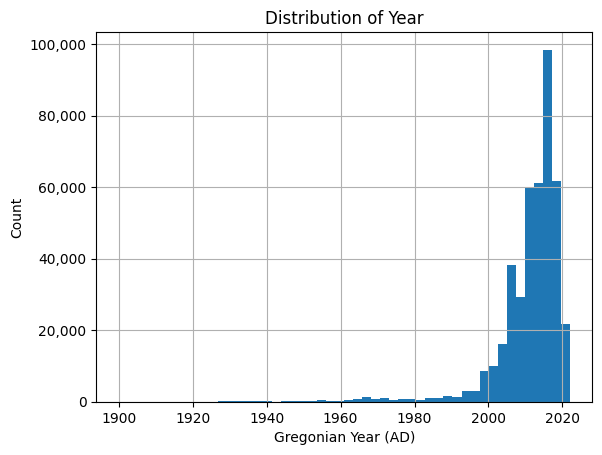

In [7]:
# Create a boolean mask to check year
mask = df['year'].notna()
# Select the 'year' column using this mask and plot its histogram
ax = df.loc[mask, ['year']].hist(bins=50)
plt.title('Distribution of Year')
plt.xlabel('Gregonian Year (AD)')
plt.ylabel('Count')

# Format y-axis tick labels with commas (ax is a 2D array of subplots, we access the first one)
formatter = mticker.StrMethodFormatter('{x:,.0f}')
ax[0, 0].yaxis.set_major_formatter(formatter)

plt.show()

**Business takeaway:**  According to the [US Bureau of Transportation Statistics](https://www.bts.gov/content/average-age-automobiles-and-trucks-operation-united-states), the average age of automobiles and trucks in operation in the United States between `2016` and `2025` was between `11.5` to `14 `years. Furthermore, according to [autorecyclingworld.com](https://autorecyclingworld.com/what-is-the-lifespan-of-a-vehicle-in-the-usa/), among US states, the average lifespan of vehicles with the longest lifespan is `18.6` years. Therefore, we can conservatively select `25` years as the maximum life of a used-car in `fair` condition that the model can be expected to perform a prediction on.

Using the above statistics, and knowing that the upper limit for model year in the dataset is `2022`, by keeping a conservative age limit of 25 years, we can get a cut-off model year for the lower limit of `1997` for model `year`. Beyond `1997` we end up in vintage car territory, and with few observations for such older model years, we would not have an accurate model anyway. It would be best to restrict the model to a reasonable end-of-life model year range, which would likely correspond to the business objective of used-car dealerships also trading in recent model year cars.

In [8]:
# Get all rows with year outlier
year_lower = 1997
year_upper = 2022
mask = df['year'].gt(year_upper) | df['year'].lt(year_lower)
print(f"Mask match count: {mask.sum()}")
out_year_cars = df.loc[mask, ['year']].sort_values(
    by='year', ascending=False
)
print(
    f"\nNumber of cars with abnormal year: {year_lower} "
    f"> year  > {year_upper}: {len(out_year_cars)}"
)
display(out_year_cars)


Mask match count: 18444

Number of cars with abnormal year: 1997 > year  > 2022: 18444


,year
273,1996.0
426418,1996.0
426339,1996.0
426815,1996.0
147891,1996.0
...,...
95914,1900.0
96564,1900.0
32544,1900.0
94319,1900.0


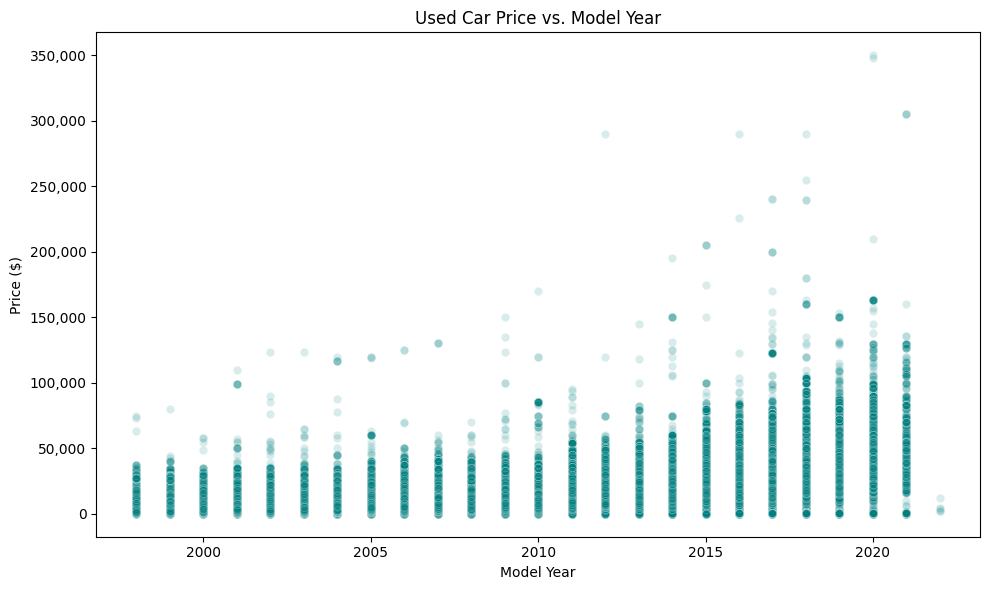

In [50]:
# Create a scatter plot of price vs. year
plt.figure(figsize=(10, 6))
sns.scatterplot(data=clean_8_df, x='year', y='price', alpha=0.15, color='teal')

# Set labels and title
plt.title('Used Car Price vs. Model Year')
plt.xlabel('Model Year')
plt.ylabel('Price ($)')

# Format the y-axis to show commas for currency values
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.tight_layout()
plt.show()

#### Odometer distribution analysis:

Let's check the data distribution of the `odometer` field. Odometer is an important feature and has a strong correlation with price. Generally, higher mileage cars are cheaper.

Mask match count: 419939


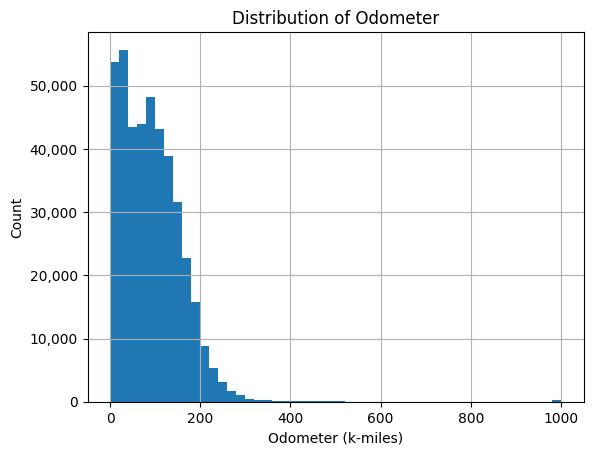

In [9]:
# Create a boolean mask where odometer is not NaN AND is between 1 and 1,000,000
odometer_upper = 1000000
mask = df['odometer'].notna() & df['odometer'].between(1, odometer_upper)
print(f"Mask match count: {mask.sum()}")

# Create a copy of the selected odometer values and
# divide by 1000 for k-miles representation.
odometer_k_miles = df.loc[mask, 'odometer'] / 1000

# Plot the histogram
ax = odometer_k_miles.hist(bins=50)
plt.title('Distribution of Odometer')
plt.xlabel('Odometer (k-miles)')
plt.ylabel('Count')

# Format y-axis tick labels with commas
formatter = mticker.StrMethodFormatter('{x:,.0f}')
ax.yaxis.set_major_formatter(formatter)

plt.show()

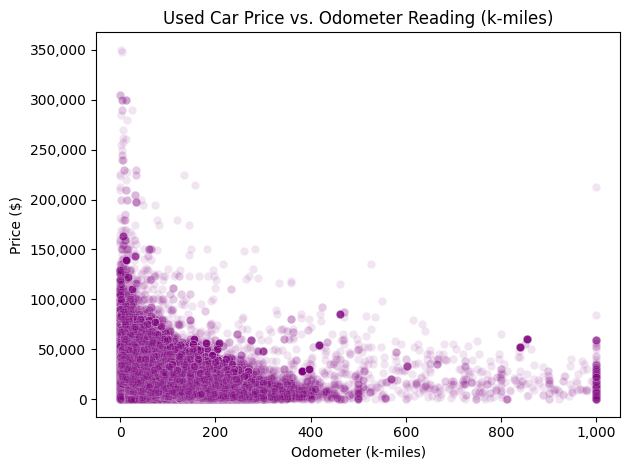

In [10]:
# Filter to get clean data for plotting, using similar criteria as before
temp_plot_df = df[
    df['odometer'].notna() &
    df['odometer'].between(1, 1000000) &
    df['price'].notna() &
    df['price'].between(1, 350000)
].copy()

# Convert odometer to k-miles
temp_plot_df['odometer_k_miles'] = temp_plot_df['odometer'] / 1000

# plt.figure(figsize=(10, 6))
sns.scatterplot(data=temp_plot_df, x='odometer_k_miles', y='price', alpha=0.1, color='purple')

# Format titles and labels
plt.title('Used Car Price vs. Odometer Reading (k-miles)')
plt.xlabel('Odometer (k-miles)')
plt.ylabel('Price ($)')

# Format tick marks with commas for readability
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

**Business takeaway:** The `odometer` distribution is highly skewed towards values below `600k` miles. Beyond this upper limit, and as verified by the scatter plot of odometer vs. price, we have relatively small amount of data and generally falling price with higher mileage. Besides trucks, vehicles with such high mileage are considered end-of-life. It may be prudent to set the upper-limit for the odometer mileage to be `600k` instead of `1M`.

In [11]:
# Get all rows with odometer outlier values
odometer_upper = 1000000
mask = df['odometer'].gt(odometer_upper) | df['odometer'].lt(1)
print(f"Mask match count: {mask.sum()}")

out_mileage_cars = df.loc[mask, ['odometer']].sort_values(
    by='odometer', ascending=False
)
msg = (
    f"\nNumber of cars with abnormal mileage < 1 and > "
    f"{odometer_upper:,}: {len(out_mileage_cars)}"
)
print(msg)
display(out_mileage_cars)


Mask match count: 2541

Number of cars with abnormal mileage < 1 and > 1,000,000: 2541


,odometer
81327,10000000.0
106192,10000000.0
106542,10000000.0
108797,10000000.0
390252,10000000.0
...,...
185221,0.0
176286,0.0
176330,0.0
176655,0.0


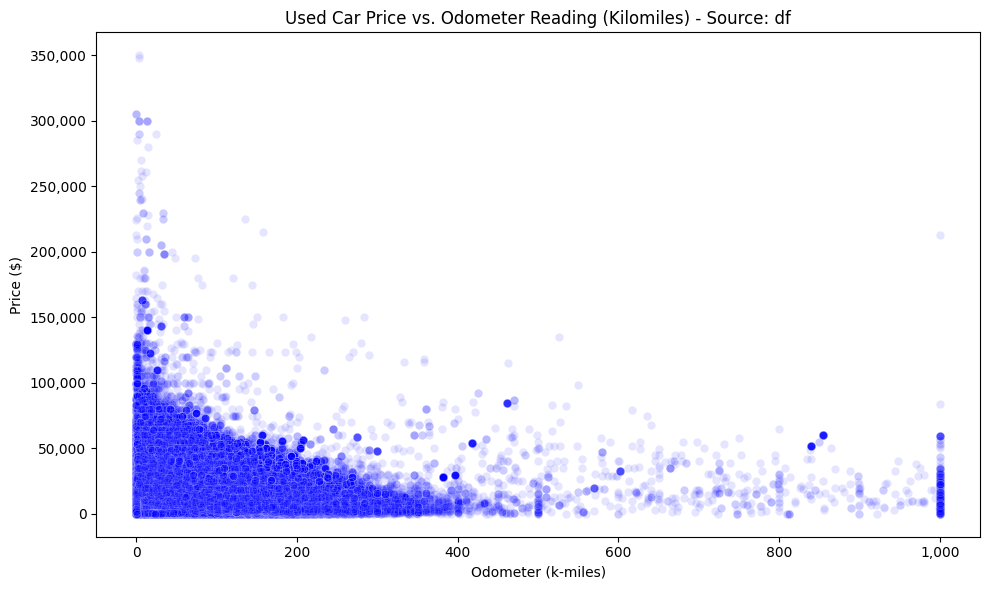

In [12]:

# Filter df to handle missing values and extreme outliers for plotting
# Keeping odometer values between 1 and 1,000,000 and prices under $350,000
temp_df = df[
    df['odometer'].notna() &
    df['odometer'].between(1, 1000000) &
    df['price'].notna() &
    df['price'].between(1, 350000)
].copy()

# Create kilomiles feature
temp_df['odometer_k_miles'] = temp_df['odometer'] / 1000

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=temp_df, x='odometer_k_miles', y='price', alpha=0.1, color='blue')

# Format axis and titles
plt.title('Used Car Price vs. Odometer Reading (Kilomiles) - Source: df')
plt.xlabel('Odometer (k-miles)')
plt.ylabel('Price ($)')

# Format axes with commas
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

#### Price distribution analysis:

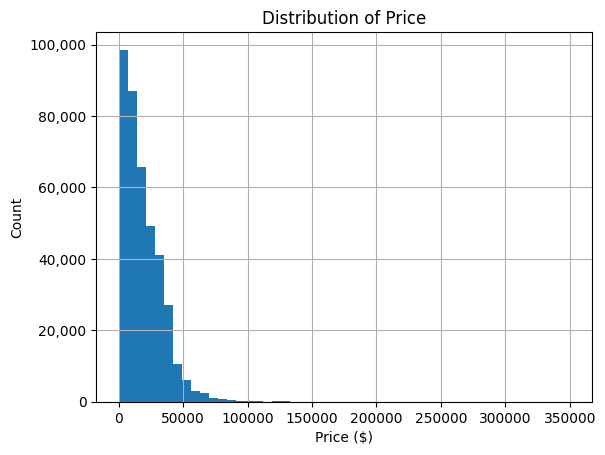

In [13]:
# Let's check the price distribution using a histogram plot.
price_upper = 350000
mask = df['price'].notna() & df['price'].between(1, price_upper)
ax = df.loc[mask, ['price']].hist(bins=50)
plt.title('Distribution of Price')
plt.xlabel('Price ($)')
plt.ylabel('Count')

# Format y-axis tick labels with commas
formatter = mticker.StrMethodFormatter('{x:,.0f}')
ax[0, 0].yaxis.set_major_formatter(formatter)

plt.show()


In [14]:
# Get all rows with price values greater than $350k
price_upper = 350000
expensive_cars = df.loc[df['price'].dropna().gt(price_upper)].sort_values(
    by='price', ascending=False
)
print(f"\nNumber of cars with price > ${price_upper:,}: {len(expensive_cars)}")
display(expensive_cars)


Number of cars with price > $350,000: 72


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
356716,7302445002,knoxville,3736928711,1999.0,toyota,4runner,fair,6 cylinders,gas,211000.0,clean,automatic,NaN,4wd,mid-size,NaN,green,tn
318592,7308056031,eugene,3736928711,2007.0,toyota,tundra,excellent,8 cylinders,gas,164000.0,clean,automatic,NaN,4wd,full-size,pickup,silver,or
257840,7309735768,south jersey,3024942282,2000.0,mercedes-benz,benz s430,NaN,NaN,gas,100000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,nj
91576,7309730903,delaware,3024942282,2000.0,mercedes-benz,benz e320,NaN,NaN,gas,100000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,de
37410,7314052904,modesto,3009548743,2021.0,chevrolet,NaN,NaN,8 cylinders,gas,1000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,ca
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106361,7313051670,orlando,516999,2016.0,NaN,Lambo Aventador SV Roadster,like new,12 cylinders,gas,9982.0,clean,automatic,NaN,4wd,full-size,convertible,white,fl
113357,7314803400,south florida,470000,2016.0,NaN,hINO 268,good,NaN,diesel,167268.0,clean,automatic,NaN,NaN,NaN,NaN,white,fl
360604,7312429759,nashville,449500,2019.0,ferrari,488 gtb,NaN,NaN,gas,500.0,clean,NaN,ZFF79ALA7K0248037,NaN,NaN,coupe,red,tn
133497,7316029298,east idaho,425000,1993.0,jeep,wrangler,NaN,NaN,gas,380.0,clean,automatic,NaN,NaN,NaN,NaN,red,id


**Business takeaway:**
We can clearly see from the histogram and percentile distribution, that the majority of the price data is below `$80,000`. There are some values that seem legitimate upto `$300,000`. All price values above `$300,000` seem incorrect or made up (such as `$1,234,567`.

We should drop outliers above the `$350,000` price point due to low data observations above that price and the possibility of inaccurate data, which would inevitably produce inaccurate prediction models.

#### Check low-cardinality features:

In [15]:
# Let's check the values available in low-cardinality categorical columns
# so we can understand the data better.
low_ord_cat_col_names = [
    'manufacturer', 'condition', 'cylinders', 'fuel', 'transmission',
    'drive', 'title_status', 'size', 'type']
for col_name in low_ord_cat_col_names:
    col_values = df[col_name].unique()
    print(f"{col_name}(unique value count: {len(col_values)}): {col_values}")


manufacturer(unique value count: 43): [nan 'gmc' 'chevrolet' 'toyota' 'ford' 'jeep' 'nissan' 'ram' 'mazda'
 'cadillac' 'honda' 'dodge' 'lexus' 'jaguar' 'buick' 'chrysler' 'volvo'
 'audi' 'infiniti' 'lincoln' 'alfa-romeo' 'subaru' 'acura' 'hyundai'
 'mercedes-benz' 'bmw' 'mitsubishi' 'volkswagen' 'porsche' 'kia' 'rover'
 'ferrari' 'mini' 'pontiac' 'fiat' 'tesla' 'saturn' 'mercury'
 'harley-davidson' 'datsun' 'aston-martin' 'land rover' 'morgan']
condition(unique value count: 7): [nan 'good' 'excellent' 'fair' 'like new' 'new' 'salvage']
cylinders(unique value count: 9): [nan '8 cylinders' '6 cylinders' '4 cylinders' '5 cylinders' 'other'
 '3 cylinders' '10 cylinders' '12 cylinders']
fuel(unique value count: 6): [nan 'gas' 'other' 'diesel' 'hybrid' 'electric']
transmission(unique value count: 4): [nan 'other' 'automatic' 'manual']
drive(unique value count: 4): [nan 'rwd' '4wd' 'fwd']
title_status(unique value count: 7): [nan 'clean' 'rebuilt' 'lien' 'salvage' 'missing' 'parts only']
size

**Business takeaway:**
All of these categorical columns have `nan` values. We can drop such observations (rows) as their counts are small relative to the size of the dataset.

#### Manufacturer distribution analysis:

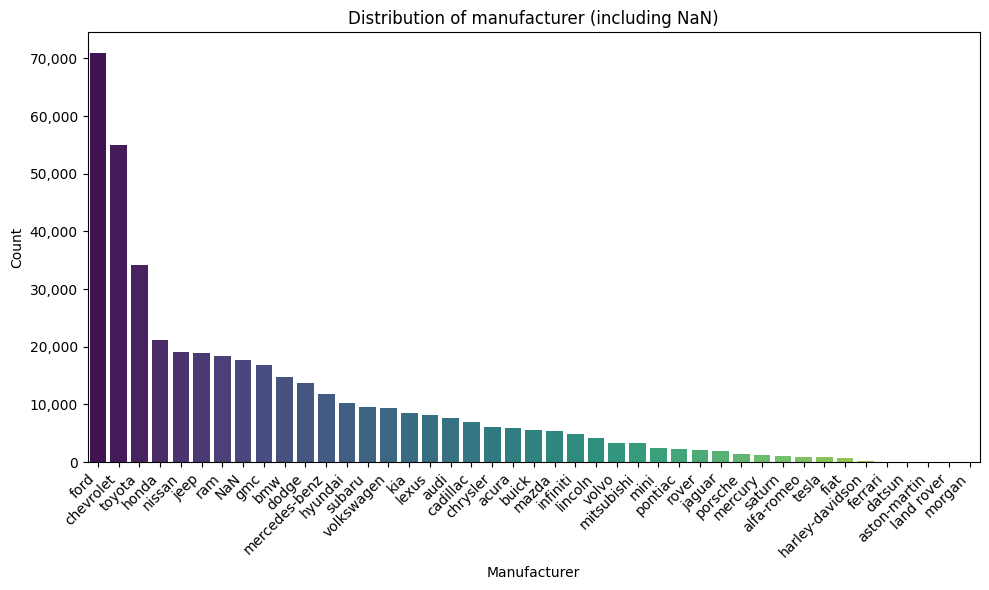

In [16]:
# Get manufacturer count including NaN values
mfg_counts = df['manufacturer'].value_counts(dropna=False)

# Replace NaN index with string for plotting
mfg_counts.index = mfg_counts.index.fillna('NaN')

# Set a larger figure size for better label spacing
plt.figure(figsize=(10, 6))

# Plot
ax = sns.barplot(x=mfg_counts.index, y=mfg_counts.values, palette='viridis')

plt.title('Distribution of manufacturer (including NaN)')
plt.xlabel('Manufacturer')
plt.ylabel('Count')

# Rotate labels and align them for readability
plt.xticks(rotation=45, ha='right')

# Format y-axis with commas
import matplotlib.ticker as mticker
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

#### Fuel type distribution analysis:

The `field` column lists the fuel type the car's propulsion system is based on.

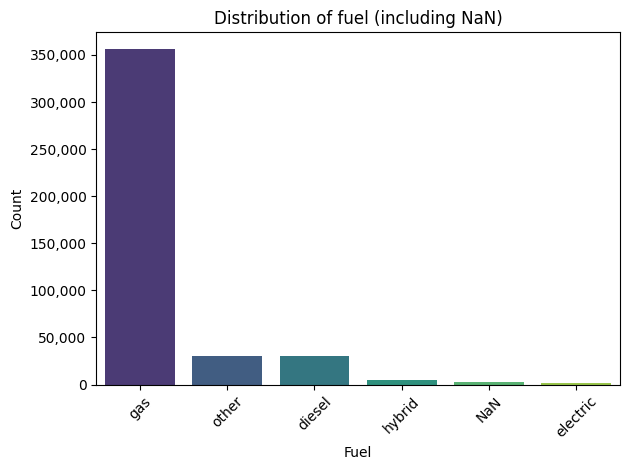

In [17]:
# Get fuel count including NaN values
fuel_counts = df['fuel'].value_counts(dropna=False)

# Replace NaN index with string for plotting
fuel_counts.index = fuel_counts.index.fillna('NaN')

# Plot
ax = sns.barplot(x=fuel_counts.index, y=fuel_counts.values,
                 palette='viridis')

plt.title('Distribution of fuel (including NaN)')
plt.xlabel('Fuel')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Format y-axis with commas
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

**Business takeway:** The car's `fuel` type column is an extremely important feature and can be a strong predictor of price of a used-car. There is also very low missing data in this field so it would be good to keep this field. The one concerning point about the `fuel` field is the `other` value, which is ambiguous.

#### Transmission distribution analysis:

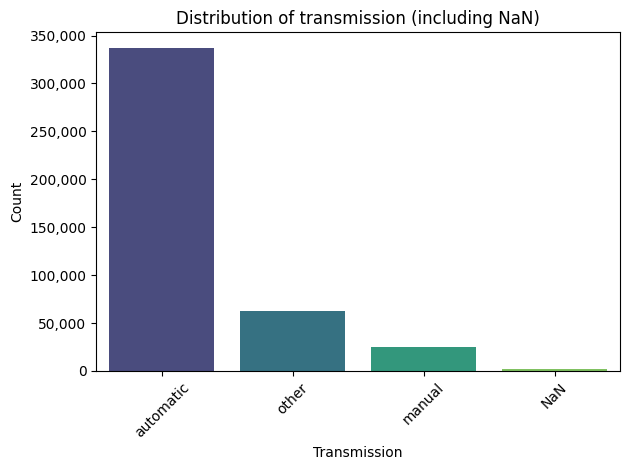

In [18]:
# Get transmission count including NaN values
transmission_counts = df['transmission'].value_counts(dropna=False)

# Replace NaN index with string for plotting
transmission_counts.index = transmission_counts.index.fillna('NaN')

# Plot
ax = sns.barplot(x=transmission_counts.index, y=transmission_counts.values,
                 palette='viridis')

plt.title('Distribution of transmission (including NaN)')
plt.xlabel('Transmission')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Format y-axis with commas
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

#### Car `type` distribution analysis:

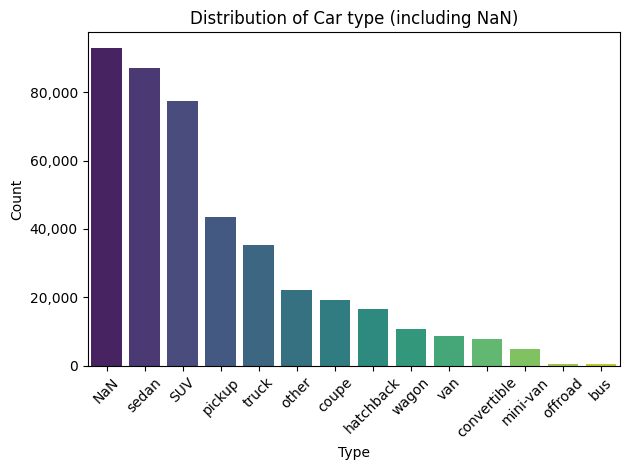

In [19]:
# Get type count including NaN values
type_counts = df['type'].value_counts(dropna=False)

# Replace NaN index with string for plotting
type_counts.index = type_counts.index.fillna('NaN')

# Plot
ax = sns.barplot(x=type_counts.index, y=type_counts.values,
                 palette='viridis')

plt.title('Distribution of Car type (including NaN)')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Format y-axis with commas
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

#### Condition distribution analysis:

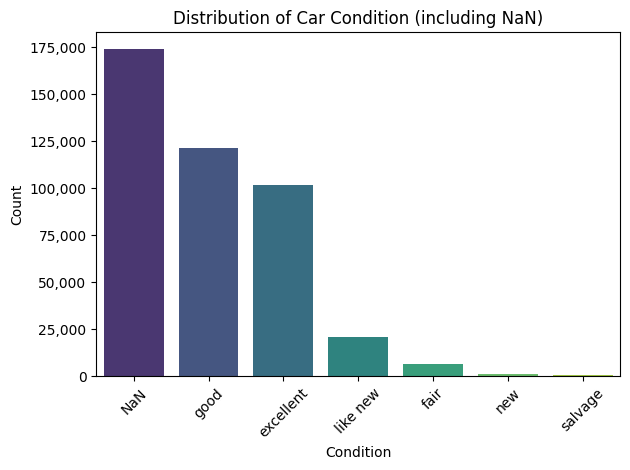

In [20]:
# Get condition count including NaN values
condition_counts = df['condition'].value_counts(dropna=False)

# Replace NaN index with string for plotting
condition_counts.index = condition_counts.index.fillna('NaN')

# Plot
ax = sns.barplot(x=condition_counts.index, y=condition_counts.values,
                 palette='viridis')

plt.title('Distribution of Car Condition (including NaN)')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Format y-axis with commas
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

**Business takeaway:**

The `condition` field is interesting beause although it has a high percentage of missing data (40%) as shown in the missing values analysis, it also shows that there is some data for `new` and `salvage` cars as well.

We will need to carefully prune the observations (rows) using the values in the `condition` field before dropping the column altogether.

We can drop observations with `new` values, because we are building a used car model and having data for new cars would mis-lead the model. There are very few `new` car observations anyway, so it will not affect the data quantity too much.

Furthermore, we can drop observations (rows) with `salvage` values, as the number of observations in this category is very small and will make the model rigid and not generalizable.

Although we cannot definitively say that `Nan` valued observations represent used-cars, we will keep the remaining observations with `NaN`, `good`, `excellent` and `like new` values and assume them as observations for used cars.

After clearing the `new` and `salvage` valued observations, we will drop the `condition` column altogether.

#### Check high-cadinality features:

In [21]:
# Check columns/features with high-cardinality
print("\nSample id[] data:")
print(df['id'].sample(5))
print("\nSample VIN[] data:")
print(df['VIN'].sample(5))
print("\nSample region[] data:")
print(df['region'].sample(5))
print("\nSample model[] data:")
print(df['model'].sample(5))


Sample id[] data:
23402     7303727963
270883    7307360734
241162    7314513882
155270    7302176066
38946     7307673625
Name: id, dtype: int64

Sample VIN[] data:
142985    WBA3B9C55DJ437184
257955                  NaN
324648    KNDPCCA62C7298461
364328    1GCUYBEF3KZ253816
113710                  NaN
Name: VIN, dtype: object

Sample region[] data:
407908    seattle-tacoma
203566           jackson
169956           wichita
283214     new hampshire
287322    akron / canton
Name: region, dtype: object

Sample model[] data:
187436        impala lt
63350             f-150
264383         forester
335790            f-150
53952     Isuzu Trooper
Name: model, dtype: object


In [22]:
# Let's also check categorical columns that have high-cardinality 'id' and 'VIN'
uniq_model_cnt = df['model'].nunique()
uniq_id_cnt = df['id'].nunique()
uniq_vin_cnt = df['VIN'].nunique()

ndf = len(df)
print(f"Number of unique values in 'model': {uniq_model_cnt:,} out of {ndf:,} rows")
print(f"Number of unique values in 'id': {uniq_id_cnt:,} out of {ndf:,} rows")
print(f"Number of unique values in 'VIN': {uniq_vin_cnt:,} out of {ndf:,} rows")

Number of unique values in 'model': 29,649 out of 426,880 rows
Number of unique values in 'id': 426,880 out of 426,880 rows
Number of unique values in 'VIN': 118,246 out of 426,880 rows


**Business takeaway:**
Seems like the feature column `id` has all unique values, which is to be expected.

However, there are many duplicate occurances in the `VIN` column. This could be due to the fact that the same car is being sold multiple times during its lifetime.

In [23]:
# Get a random sample of unique values in the 'region' column
unique_regions = df['region'].unique()
sample_regions = pd.Series(unique_regions).sample(15, random_state=42).values
print(f"Total unique regions: {len(unique_regions)}")
print("Sample of unique regions:")
print(sample_regions)

Total unique regions: 404
Sample of unique regions:
['high rockies' 'joplin' 'moses lake' 'jonesboro' 'imperial county'
 'washington, DC' 'south bend / michiana' 'pierre / central SD' 'waco'
 'ithaca' 'victoria' 'delaware' 'cleveland' 'seattle-tacoma'
 'southeast KS']


In [24]:
# Get a random sample of unique values in the 'state' column
unique_states = df['state'].unique()
sample_states = pd.Series(unique_states).sample(min(15, len(unique_states)), random_state=42).values
print(f"Total unique states: {len(unique_states)}")
print("Sample of unique states:")
print(sample_states)

Total unique states: 51
Sample of unique states:
['sc' 'oh' 'ut' 'ak' 'ks' 'ms' 'de' 'mo' 'ma' 'mn' 'ca' 'tx' 'wv' 'or'
 'vt']


#### Geographical Location features `region` and `state`:

It seems, the areas listed in the `region` feature column are smaller geographical areas such as *cities* or *greater contiguous metropolitan areas*. Furthermore, there are a large number of unique regions (`32`) with an even larger number of (`51`) states. To simplify the prediction model, it would be best to drop both the `region` and `state` features not base price on geographic location.

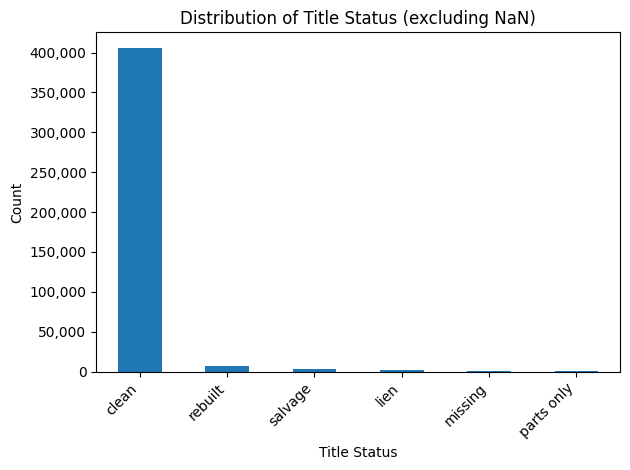

In [25]:
import matplotlib.ticker as mticker

# Lets check title status field
ax = df['title_status'].value_counts(dropna=True).plot(kind='bar')
plt.title('Distribution of Title Status (excluding NaN)')
plt.xlabel('Title Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Format y-axis tick labels with commas
formatter = mticker.StrMethodFormatter('{x:,.0f}')
ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

#### Filter `title_status`:

As we can see from the `title_status` distribution, most of the data is contained withing `clean` titles. Due to the extreme skew in the data, it is best that we filter out all other title states and keep only `clean` titles. It would make a better model if we dropped the `title_status` field altogether and made a business restriction that model can be used to predict used car prices for `clean` titles only.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

#### Steps for Data Preparation:

Here are the steps we will perform after the Data Understanding Phase:
- Remove feature columns that have many missing values, to produce clean data;
- Remove observations (rows) with any missing values to produce clean data;
- Remove observations (rows) with categorical values such as `"unknown"` that represent a missing value;
- Remove categorical features such as `id` and `VIN` with *high-cardinality* that also contain information that is largely unique to each vehicle and do not help generalize the model;
- Use One-hot encoding to transform categorical features for model regression;
- The `year` feature should be converted to the `vehicle age` feature, which is more generalizable towards a predictive model. The vehicle model `year`, in-fact, is used to determine the age of the car at the time of sale. However, since we do not have the sale date in the datset columns, this transformation *cannot* be achieved.
- The clean data can be devided into 3 sets: 70% train, 15% validation/development, and 15% test.

#### Drop columns with many null values:

In [26]:
# Drop columns with many null values first
clean_1_df = df.drop(
    columns=['size', 'cylinders', 'VIN', 'drive', 'paint_color'],
    axis=1
)
print(f"[1] Shape Original: ({df.shape[0]:,}, {df.shape[1]})")
print(f"[1] Shape after dropping columns: ({clean_1_df.shape[0]:,}, {clean_1_df.shape[1]})\n")


[1] Shape Original: (426,880, 18)
[1] Shape after dropping columns: (426,880, 13)



In [27]:
# Drop rows where condition is 'new' or 'salvage'
# Note that we keep NaN, 'good', 'excellent', 'like new', and 'fair' values
clean_2_df = clean_1_df.loc[~clean_1_df['condition'].isin(['new', 'salvage'])]

print(f"[2] Shape Original: ({df.shape[0]:,}, {df.shape[1]})")
print(f"[2] Shape after dropping 'new' and 'salvage': ({clean_2_df.shape[0]:,}, {clean_2_df.shape[1]})\n")

# Drop the 'condition' column entirely as planned
clean_2_df = clean_2_df.drop(columns=['condition'], axis=1)

print(f"Shape after filtering and dropping 'condition' column: ({clean_2_df.shape[0]:,}, {clean_2_df.shape[1]})")

[2] Shape Original: (426,880, 18)
[2] Shape after dropping 'new' and 'salvage': (424,974, 13)

Shape after filtering and dropping 'condition' column: (424,974, 12)


#### Drop columns with high-cardinality

In [28]:
# Drop columns with high-cardinality; Ignore those already dropped.
clean_3_df = clean_2_df.drop(columns=['id', 'region', 'model', 'state'], axis=1)

print(f"[3] Shape Original: ({df.shape[0]:,}, {df.shape[1]})")
print(f"[3] Shape after dropping columns: ({clean_3_df.shape[0]:,}, {clean_3_df.shape[1]})\n")



[3] Shape Original: (426,880, 18)
[3] Shape after dropping columns: (424,974, 8)



In [29]:
# Drop all title_status values except title_status == 'clean'
clean_4_df = clean_3_df.loc[clean_3_df['title_status'].eq('clean')]
clean_4_df = clean_4_df.drop(columns=['title_status'], axis=1)
print(f"[4] Shape Original: ({df.shape[0]:,}, {df.shape[1]})")
print(f"[4] Shape after dropping more columns and rows: ({clean_4_df.shape[0]:,}, {clean_4_df.shape[1]})\n")


[4] Shape Original: (426,880, 18)
[4] Shape after dropping more columns and rows: (403,666, 7)



#### Drop observations with null values:

In [30]:
# Drop rows with null values from the dataset
clean_5_df = clean_4_df.dropna()
print(f"Shape Original: ({df.shape[0]:,}, {df.shape[1]})")
print(f"Shape after dropping all rows with null values: {clean_5_df.shape}")

Shape Original: (426,880, 18)
Shape after dropping all rows with null values: (300071, 7)


#### Drop outliers in `price`:

In [31]:
# Drop outliers where price <= 1 or price > 350000
clean_6_df = clean_5_df.loc[clean_5_df['price'].gt(1) & clean_5_df['price'].le(350000)]

print(f"Shape after dropping price outliers: {clean_6_df.shape}")
display(clean_6_df['price'].describe().to_frame().style.format('{:,.0f}'))

Shape after dropping price outliers: (275657, 7)


,price
count,"275,657"
mean,"20,124"
std,"14,773"
min,3
25%,"8,499"
50%,"16,999"
75%,"28,990"
max,"349,999"


#### Drop outliers in `year`:

In [32]:
clean_7_df = clean_6_df.loc[~
    (clean_6_df['year'].le(year_lower))
]
print(f"Shape Original: ({df.shape[0]:,}, {df.shape[1]})")
print(f"Shape after dropping all rows with null values: {clean_7_df.shape}")

Shape Original: (426,880, 18)
Shape after dropping all rows with null values: (265940, 7)


#### Drop outliers in `odometer`:

In [48]:
# Drop outliers in odometer as found in Data Exploration Phase
clean_8_df = clean_7_df.loc[
    (clean_7_df['odometer'].gt(1) & clean_7_df['odometer'].le(1000000))
]
print(f"Shape Original: ({df.shape[0]:,}, {df.shape[1]})")
print(f"Shape after dropping all rows with null values: {clean_8_df.shape}\n")
clean_8_df.info()

Shape Original: (426,880, 18)
Shape after dropping all rows with null values: (264818, 7)

<class 'pandas.core.frame.DataFrame'>
Index: 264818 entries, 27 to 426879
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         264818 non-null  int64  
 1   year          264818 non-null  float64
 2   manufacturer  264818 non-null  object 
 3   fuel          264818 non-null  object 
 4   odometer      264818 non-null  float64
 5   transmission  264818 non-null  object 
 6   type          264818 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 16.2+ MB


#### Convert categorical columns using one-hot encoding:

In [34]:
# Use one-hot encoding to convert remaining categorical features to numerical features
# We identify all categorical features (columns with 'object' data type)
processed_df = clean_8_df
categorical_cols = processed_df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

# Convert to numerical features using pandas get_dummies;
df_encoded = pd.get_dummies(processed_df, columns=categorical_cols, drop_first=True)

print(f"Dataset shape after one-hot encoding: {df_encoded.shape}")
display(df_encoded.head())

Categorical columns to encode: ['manufacturer', 'fuel', 'transmission', 'type']
Dataset shape after one-hot encoding: (264729, 60)


,price,year,odometer,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,...,type_coupe,type_hatchback,type_mini-van,type_offroad,type_other,type_pickup,type_sedan,type_truck,type_van,type_wagon
27,33590,2014.0,57923.0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
28,22590,2010.0,71229.0,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
29,39590,2020.0,19160.0,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
30,30990,2017.0,41124.0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
31,15000,2013.0,128000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


#### Polynomial transform on Numerical columns:

In [35]:
# Perform a polynomial transform on the numerical features to expand feature set
numeric_cols = ["year", "odometer"]

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_array = poly.fit_transform(df_encoded[numeric_cols])
poly_names = poly.get_feature_names_out(numeric_cols)

print(f"{len(numeric_cols)} numeric columns in, {len(poly_names)} features out:")
print(list(poly_names))

2 numeric columns in, 5 features out:
['year', 'odometer', 'year^2', 'year odometer', 'odometer^2']


#### Combine numerical and categorical columns:

In [36]:
dummy_cols = [c for c in df_encoded.columns if c not in numeric_cols + ["price"]]

X_full = pd.concat([
    pd.DataFrame(poly_array, columns=poly_names),
    df_encoded[dummy_cols].reset_index(drop=True),
], axis=1)
y = df_encoded["price"].reset_index(drop=True)

print(f"Total features available to the model: {X_full.shape[1]}")
X_full.head(3)

Total features available to the model: 62


,year,odometer,year^2,year odometer,odometer^2,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,...,type_coupe,type_hatchback,type_mini-van,type_offroad,type_other,type_pickup,type_sedan,type_truck,type_van,type_wagon
0,2014.0,57923.0,4056196.0,116656922.0,3.355074e+09,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,2010.0,71229.0,4040100.0,143170290.0,5.073570e+09,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,2020.0,19160.0,4080400.0,38703200.0,3.671056e+08,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


#### Split into train, validation and test sets:

In [37]:
# Let's perform an 80%/20%/20% split on the full dataset to get the
# train/validation/test datasets.
X_train, X_temp, y_train, y_temp = train_test_split(
    X_full, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Training: {len(X_train):,} Validation: {len(X_val):,} Test: {len(X_test):,}")

Training: 158,837 Validation: 52,946 Test: 52,946


In [45]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. Scale the X_full features first
scaler_pca = StandardScaler()
X_full_scaled = scaler_pca.fit_transform(X_full)

# 2. Fit PCA
pca = PCA()
pca.fit(X_full_scaled)

# 3. Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 4. Find the number of components explaining at least 95% of variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Total features in X_full: {X_full.shape[1]}")
print(f"Number of PCA components explaining 95% of the variance: {n_components_95}")
print(f"Cumulative variance explained by these {n_components_95} components: {cumulative_variance[n_components_95 - 1]:.2%}")


Total features in X_full: 62
Number of PCA components explaining 95% of the variance: 52
Cumulative variance explained by these 52 components: 96.03%


In [46]:
import pandas as pd
import numpy as np

# Get the loading matrix (components_ shape: [n_components, n_features])
# We weight the squared loadings of each feature across the principal components
# by the explained variance ratio of those components.

loadings = pca.components_[:n_components_95]
weights = pca.explained_variance_ratio_[:n_components_95]

# Calculate weighted feature contributions
weighted_contributions = np.dot(weights, (loadings ** 2))

# Create a DataFrame to display the features and their importances
feature_importance_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Variance_Contribution_Score': weighted_contributions
}).sort_values(by='Variance_Contribution_Score', ascending=False)

print("Original features in decreasing order of variance contribution in the PCA:")
display(feature_importance_df.head(20))


Original features in decreasing order of variance contribution in the PCA:


,Feature,Variance_Contribution_Score
25,manufacturer_land rover,0.016128
6,manufacturer_aston-martin,0.016126
50,type_bus,0.016120
18,manufacturer_harley-davidson,0.016115
55,type_offroad,0.016114
32,manufacturer_mitsubishi,0.016113
14,manufacturer_ferrari,0.016112
35,manufacturer_porsche,0.016109
15,manufacturer_fiat,0.016102
22,manufacturer_jaguar,0.016078


#### Sequential Feature Selection:

Since we have 64 features, we need to narrow down our feature-set to get a more robust generalizable model, avoid overfitting and a model which is easier to train. We will use scikit-learn's built-in SequentialFeatureSelector to select 32 features.


In [38]:
X_train_val = pd.concat([X_train, X_val]).reset_index(drop=True)
y_train_val = pd.concat([y_train, y_val]).reset_index(drop=True)

validation_fold = [-1] * len(X_train) + [0] * len(X_val)
predefined_split = PredefinedSplit(validation_fold)

sfs = SequentialFeatureSelector(
    LinearRegression(), n_features_to_select=32, direction="forward",
    scoring="neg_mean_squared_error", cv=predefined_split,
)
sfs.fit(X_train_val, y_train_val)

print(list(X_full.columns[sfs.get_support()]))
X_selected = X_full.loc[:, sfs.get_support()]

['year', 'odometer', 'year^2', 'year odometer', 'manufacturer_audi', 'manufacturer_bmw', 'manufacturer_cadillac', 'manufacturer_ferrari', 'manufacturer_fiat', 'manufacturer_gmc', 'manufacturer_hyundai', 'manufacturer_kia', 'manufacturer_lexus', 'manufacturer_mazda', 'manufacturer_mercedes-benz', 'manufacturer_mitsubishi', 'manufacturer_nissan', 'manufacturer_porsche', 'manufacturer_rover', 'manufacturer_tesla', 'manufacturer_volkswagen', 'fuel_electric', 'fuel_gas', 'fuel_hybrid', 'fuel_other', 'type_convertible', 'type_coupe', 'type_hatchback', 'type_other', 'type_pickup', 'type_sedan', 'type_truck']


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

#### Steps for Modeling:
- First, we scale the data to normalize it
- Linear Regression Model
- Regularization Regression Models:
  - Ridge regression models (L2 regularization)
  - Lasso regression models (L1 regularization)



#### Scale the data:

In [39]:
# Let's scale the data to normalize it
train_scaler = StandardScaler().fit(X_train)
X_train_scaled = train_scaler.transform(X_train)

val_scaler = StandardScaler().fit(X_val)
X_val_scaled = val_scaler.transform(X_val)

#### Ridge Regression (L2 Regularization):

In [40]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)

alphas = [0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
alpha_results = []
for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train_scaled, y_train)
    train_mse = mean_squared_error(y_train, ridge.predict(X_train_scaled))
    val_mse = mean_squared_error(y_val, ridge.predict(X_val_scaled))
    coef_size = np.sqrt(np.sum(ridge.coef_ ** 2))
    alpha_results.append({
        "alpha": a,
        "coefficient_size": round(coef_size, 1),
        "training_RMSE": round(np.sqrt(train_mse)),
        "validation_RMSE": round(np.sqrt(val_mse))
    })

pd.DataFrame(alpha_results)

,alpha,coefficient_size,training_RMSE,validation_RMSE
0,0.01,1135733.2,8584,8664
1,0.10,727776.1,8596,8678
2,1.00,215997.0,8648,8734
3,10.00,30078.3,8682,8770
4,100.00,12124.8,8687,8776
5,1000.00,11425.9,8689,8776
6,10000.00,9401.4,8760,8835
7,100000.00,5760.4,9452,9469
8,1000000.00,2086.5,12105,12042


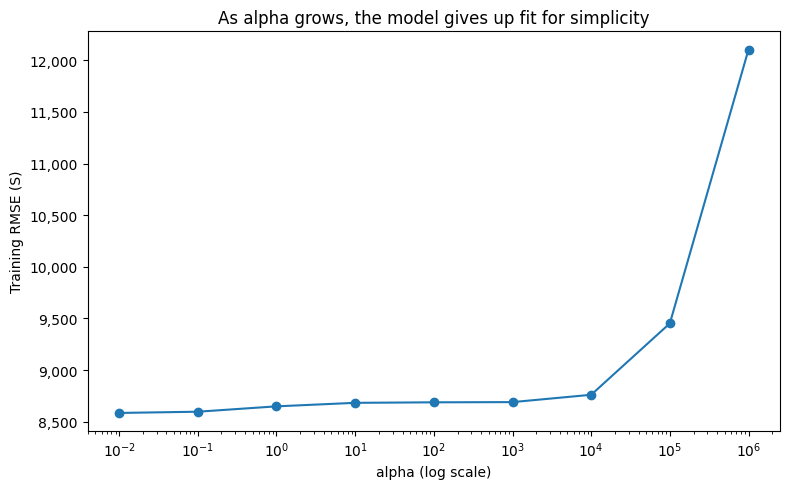

In [41]:
# Plot a graph of alpha vs RMSE
results_df = pd.DataFrame(alpha_results)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(results_df["alpha"], results_df["training_RMSE"], marker="o")
ax1.set_xscale("log")
ax1.set_xlabel("alpha (log scale)")
ax1.set_ylabel("Training RMSE (S)")
ax1.set_title("As alpha grows, the model gives up fit for simplicity")

# Format y-axis tick labels with commas
formatter = mticker.StrMethodFormatter('{x:,.0f}')
ax1.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

**Business takeaway:**
At small alphas, the training error is lower as ridge regression behavies more like linear regression. However, with higher alphas, the model is deliberately being simplified (as coeffitients shrink towards zero), and the training error rises sharply.

From the graph above, it seems after an alpha of `10^4` (10,000), the error jumps sharply. It seems 10,000 is a good alpha hyperparameter for ridge regression that simplifies the model (regularization) without significantly increasing the training error of the model.


#### Tuning alpha using `GridSearchCV`:

From the previous graph, we know the ideal alpha is closer to `10^4`. However, we need to fine-tune its value to find a better valve with optimal MSE.

In [52]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge()),
])

param_grid = {
    "ridge__alpha": [
        1000, 3000, 6000, 10000, 15000, 20000, 25000, 30000
    ]
}

grid_search = GridSearchCV(
    ridge_pipeline, param_grid,
    scoring="neg_mean_squared_error", cv=predefined_split
)
grid_search.fit(X_train_val, y_train_val)

print(f"Best alpha: {grid_search.best_params_['ridge__alpha']}")
print(f"Validation MSE at best alpha: {-grid_search.best_score_:,.0f}")
print(f"Validation RMSE at best alpha: {np.sqrt(-grid_search.best_score_):,.0f}")

Best alpha: 1000
Validation MSE at best alpha: 76,730,955
Validation RMSE at best alpha: 8,760


In [54]:
# Fit Ridge regression model with alpha=10000
ridge_model = Ridge(alpha=10000).fit(X_train_scaled, y_train)

# Create a DataFrame to match features with their coefficients
coef_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Coefficient': ridge_model.coef_
})

# Sort coefficients in descending order of absolute magnitude or direct value
coef_df['Absolute_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Absolute_Coefficient',
                              ascending=False)

print("Ridge Regression Coefficients (alpha=10000) sorted by absolute impact:")
display(coef_df.head(10))

print("Ridge Regression Coefficients (alpha=10000) sorted by absolute impact:")
display(coef_df.tail(10))


Ridge Regression Coefficients (alpha=10000) sorted by absolute impact:


,Feature,Coefficient,Absolute_Coefficient
45,fuel_gas,-4074.166570,4074.166570
3,year odometer,-2893.920600,2893.920600
1,odometer,-2845.425823,2845.425823
2,year^2,2776.041047,2776.041047
0,year,2742.826401,2742.826401
59,type_truck,2457.683682,2457.683682
47,fuel_other,-2346.179333,2346.179333
57,type_pickup,2343.463955,2343.463955
58,type_sedan,-1834.520901,1834.520901
4,odometer^2,1673.766148,1673.766148


Ridge Regression Coefficients (alpha=10000) sorted by absolute impact:


,Feature,Coefficient,Absolute_Coefficient
23,manufacturer_jeep,120.710983,120.710983
38,manufacturer_saturn,-118.719096,118.719096
18,manufacturer_harley-davidson,-74.779215,74.779215
50,type_bus,60.420831,60.420831
34,manufacturer_pontiac,-36.690241,36.690241
49,transmission_other,-31.950002,31.950002
25,manufacturer_land rover,23.782367,23.782367
60,type_van,21.078505,21.078505
30,manufacturer_mercury,-18.466807,18.466807
11,manufacturer_chevrolet,-9.197363,9.197363


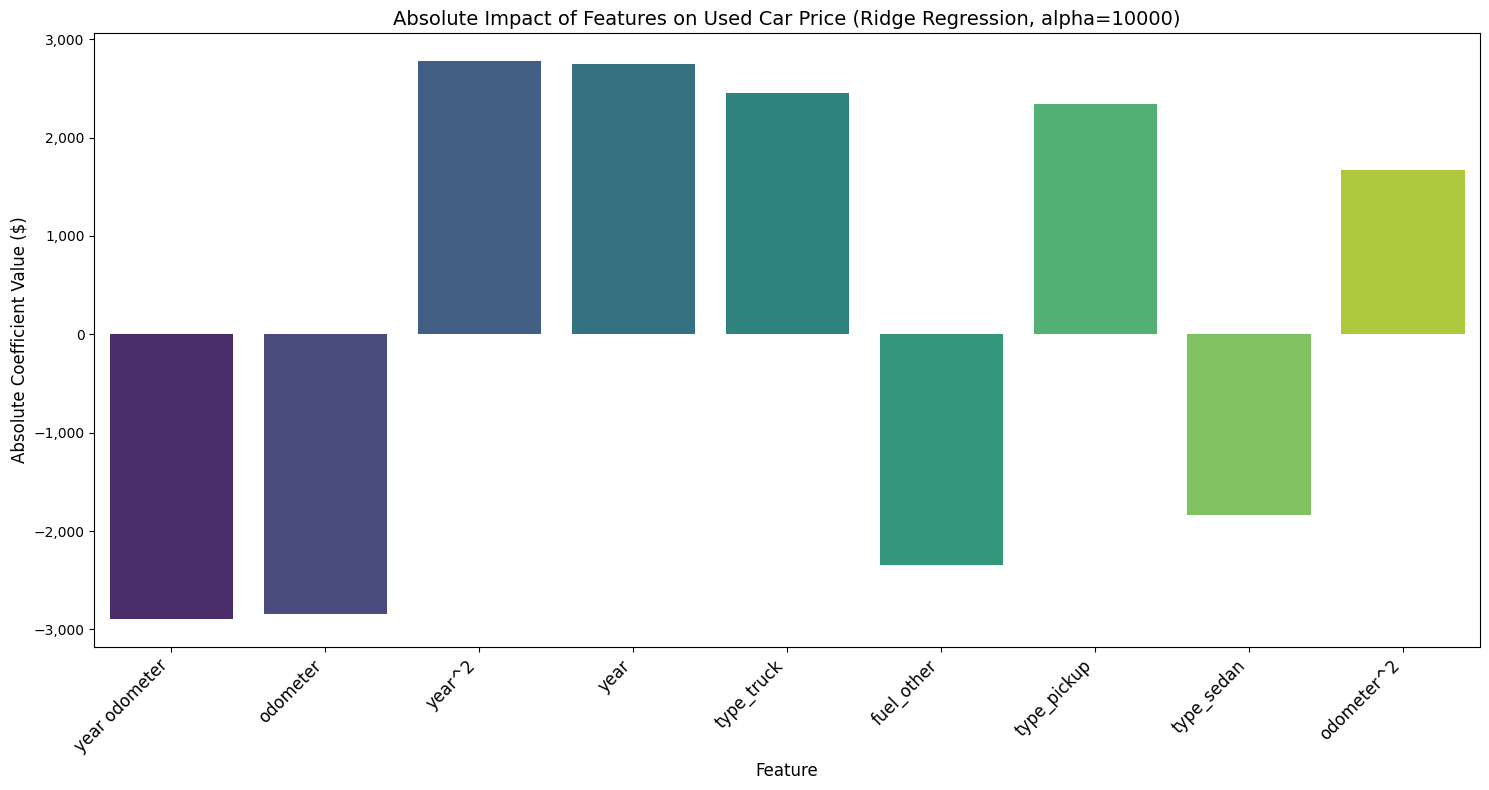

In [60]:
# Create a bar plot of Ridge regression absolute coefficients
plt.figure(figsize=(15, 8))
sns.barplot(
    data=coef_df[1:10],
    x='Feature',
    y='Coefficient',
    palette='viridis'
)

plt.title('Absolute Impact of Features on Used Car Price (Ridge Regression, alpha=10000)', fontsize=14)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Absolute Coefficient Value ($)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)

# Format the y-axis with commas
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

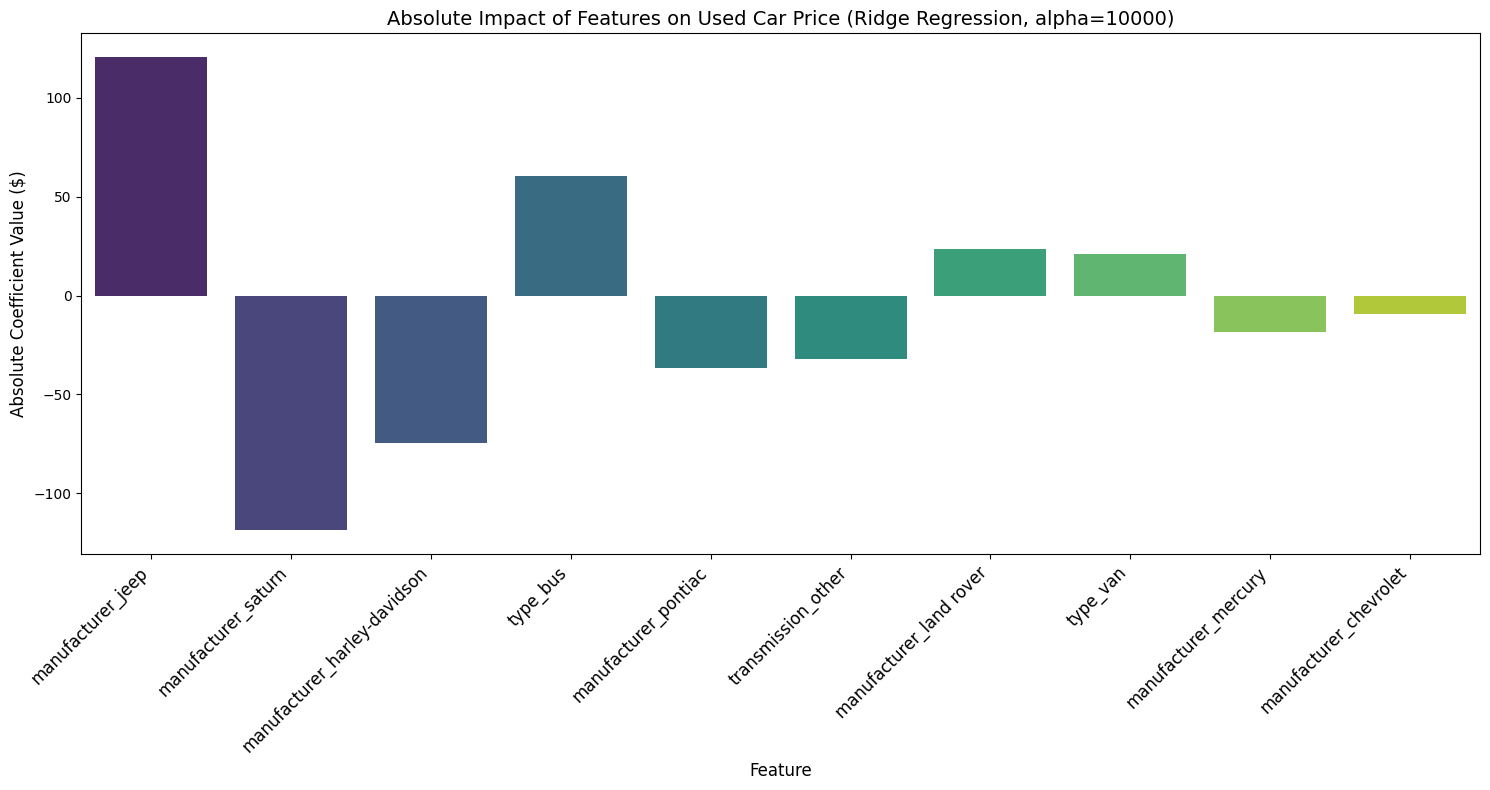

In [61]:
# Create a bar plot of Ridge regression absolute coefficients
plt.figure(figsize=(15, 8))
sns.barplot(
    data=coef_df[-10:],
    x='Feature',
    y='Coefficient',
    palette='viridis'
)

plt.title('Absolute Impact of Features on Used Car Price (Ridge Regression, alpha=10000)', fontsize=14)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Absolute Coefficient Value ($)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)

# Format the y-axis with commas
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

Here is a summary of the most prominent drivers of used car prices according to the coefficients:
- High impact features:
  - Fuel Type (`fuel_gas` -4,074.17): Having a gasoline propulsion system has a very strong negative correlation with price compared to the other fuel types such as diesel or electric. This suggests that alternative-fuel vehicles are values much higher in the used market.
  - Odometer:
    - `year-odometer` (02,893.92) and `odometer` (-2,845.43) show that both carry heavy negative coefficients, confirming that higher mileage dramatically drop a vehicle's value.
  - Year:
    - `year^2` (+2,776.04) and `year` (+2,742.83) show that positive coefficients confirm a strong npn-linear upward trajectory for newer model years. The newer the car, the higher its used price.
- Low impact features:
  - Low value manufacturer: We can see from the second bar plot of the tail end features sorted by Absolute Coefficients that certain manufacturers play a minimal influence on the price of a used-car. Manufacturers such as Chevrolet, Mercury, Pontiac, Harley Davidson (Motorcycle brand) and Saturn were the worst influencers with negative price impact. It it likely because these are all non-luxury, commodity brands, with likely lower perceived brand value that other brands in the same segment. THese brands loose their value faster than other brands.
  - Brands such as Land Rover and Jeep also have low impact on price, but their impact is at least positive. Therefore, a better bet for used-car dealerships.
  - Vehicles of type `bus` and `` also have lower impact on the price, although it is small and positive.


#### Lasso Regression (L1 regularization):


In [43]:
sparsity_results = []
for a in [10, 50, 100, 300, 500, 1000, 2000, 5000]:
    lasso = Lasso(alpha=a, max_iter=20000).fit(X_train_scaled, y_train)
    lasso_train_mse = mean_squared_error(y_train, lasso.predict(X_train_scaled))
    lasso_val_mse = mean_squared_error(y_val, lasso.predict(X_val_scaled))
    sparsity_results.append({
        "alpha": a,
        "nonzero_features": int((lasso.coef_ != 0).sum()),
        "total_features": len(lasso.coef_),
        "training_RMSE": round(np.sqrt(lasso_train_mse)),
        "validation_RMSE": round(np.sqrt(lasso_val_mse))
    })

display(pd.DataFrame(sparsity_results))

# Fit a chosen Lasso model to extract non-zero feature names
chosen_alpha = 100
final_lasso = Lasso(alpha=chosen_alpha, max_iter=20000).fit(X_train_scaled, y_train)
non_zero_indices = final_lasso.coef_ != 0
selected_features = X_full.columns[non_zero_indices].tolist()
n_selected_features = len(selected_features)

print(f"\nFeatures kept by Lasso with alpha={chosen_alpha} ({n_selected_features}):\n")
print(selected_features)

,alpha,nonzero_features,total_features,training_RMSE,validation_RMSE
0,10,60,62,8687,8774
1,50,54,62,8701,8783
2,100,51,62,8741,8818
3,300,37,62,9066,9120
4,500,27,62,9384,9411
5,1000,11,62,9955,9936
6,2000,6,62,10793,10711
7,5000,2,62,12773,12680



Features kept by Lasso with alpha=100 (51):

['year^2', 'year odometer', 'odometer^2', 'manufacturer_alfa-romeo', 'manufacturer_aston-martin', 'manufacturer_audi', 'manufacturer_bmw', 'manufacturer_buick', 'manufacturer_cadillac', 'manufacturer_chrysler', 'manufacturer_dodge', 'manufacturer_ferrari', 'manufacturer_fiat', 'manufacturer_ford', 'manufacturer_gmc', 'manufacturer_honda', 'manufacturer_hyundai', 'manufacturer_infiniti', 'manufacturer_jaguar', 'manufacturer_jeep', 'manufacturer_kia', 'manufacturer_lexus', 'manufacturer_lincoln', 'manufacturer_mazda', 'manufacturer_mercedes-benz', 'manufacturer_mini', 'manufacturer_mitsubishi', 'manufacturer_nissan', 'manufacturer_porsche', 'manufacturer_rover', 'manufacturer_saturn', 'manufacturer_subaru', 'manufacturer_tesla', 'manufacturer_toyota', 'manufacturer_volkswagen', 'manufacturer_volvo', 'fuel_electric', 'fuel_gas', 'fuel_hybrid', 'fuel_other', 'transmission_manual', 'type_convertible', 'type_coupe', 'type_hatchback', 'type_mini-v

In [64]:
# Get feature names with non-zero coefficients after Lasso regression
alpha_val = 10
lasso_model = Lasso(alpha=alpha_val, max_iter=20000).fit(X_train_scaled, y_train)

# Create a DataFrame containing all features and their corresponding coefficients
lasso_coef_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Coefficient': lasso_model.coef_
})

# Filter out zero coefficients
lasso_coef_df = lasso_coef_df[lasso_coef_df['Coefficient'] != 0]

# Sort by absolute coefficient values in descending order
lasso_coef_df['Absolute_Coefficient'] = lasso_coef_df['Coefficient'].abs()
lasso_coef_df = lasso_coef_df.sort_values(by='Absolute_Coefficient',
                                          ascending=False)

print(f"Number of non-zero features: {len(lasso_coef_df)} out of {len(X_full.columns)}")
print("\nNon-zero Lasso Regression Coefficients (alpha=10) sorted by absolute impact:")
display(lasso_coef_df.head(10))

Number of non-zero features: 60 out of 62

Non-zero Lasso Regression Coefficients (alpha=10) sorted by absolute impact:


,Feature,Coefficient,Absolute_Coefficient
3,year odometer,-8032.492352,8032.492352
2,year^2,5492.707541,5492.707541
45,fuel_gas,-5127.477491,5127.477491
4,odometer^2,3691.685193,3691.685193
47,fuel_other,-3328.406214,3328.406214
57,type_pickup,2493.630957,2493.630957
59,type_truck,2490.115640,2490.115640
58,type_sedan,-1837.674020,1837.674020
46,fuel_hybrid,-1761.848190,1761.848190
14,manufacturer_ferrari,1673.975688,1673.975688


**Business takeaway:** We can see that increasing alpha in lasso regression decreases the number of non-zero feature coefficients. The features that have zero coefficients are effectively being dropped.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

#### Evaluation Steps and Evaluation Metric:
Here are the steps for evaluation:
- We are going to evaluate the model using the validation dataset;
- We will calculate the following regression metrics for evaluation:
  - RMSE: Root Mean Squared Error;
  - The RMSE is in USD (US Dollars) and indicates the average prediction error for the model.
- The feature selection (importance), regression coefficients, can help answer business questions such as:
  - How does the model year (indirectly the age) of the car influence the price?;
  - Do certain manufacturers have higher prices (Toyota, Honda, etc.)?;
  - Which vehicle types remain more valueable even with higher mileage or age;
  - How does the odometer mileage affect price?


#### Cross-validation of 2 models using Test set:

In [65]:
# Scale X_test using the scaler fitted on X_train
X_test_scaled = train_scaler.transform(X_test)

# 1. Predict and evaluate with Ridge regression (alpha=10000)
ridge_predictions = ridge_model.predict(X_test_scaled)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))

# 2. Predict and evaluate with Lasso regression (alpha=10)
lasso_predictions = lasso_model.predict(X_test_scaled)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_predictions))

# 3. Perform 5-fold Cross Validation on the entire dataset to estimate robust generalizability
# To do this correctly, we will combine our features and target to avoid data leakage using a Pipeline
ridge_cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10000))
])

lasso_cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=10, max_iter=20000))
])

# Compute Cross-Validated MSE and convert to RMSE
kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_cv_scores = cross_val_score(ridge_cv_pipeline, X_full, y, cv=kf, scoring='neg_mean_squared_error')
ridge_cv_rmse = np.sqrt(-ridge_cv_scores.mean())

lasso_cv_scores = cross_val_score(lasso_cv_pipeline, X_full, y, cv=kf, scoring='neg_mean_squared_error')
lasso_cv_rmse = np.sqrt(-lasso_cv_scores.mean())

print(f"Ridge Model (alpha=10000) Test RMSE: ${ridge_test_rmse:,.2f}")
print(f"Ridge Model 5-Fold CV Mean RMSE:   ${ridge_cv_rmse:,.2f}\n")

print(f"Lasso Model (alpha=10) Test RMSE:  ${lasso_test_rmse:,.2f}")
print(f"Lasso Model 5-Fold CV Mean RMSE:   ${lasso_cv_rmse:,.2f}")

Ridge Model (alpha=10000) Test RMSE: $8,660.53
Ridge Model 5-Fold CV Mean RMSE:   $8,735.49

Lasso Model (alpha=10) Test RMSE:  $8,585.83
Lasso Model 5-Fold CV Mean RMSE:   $8,686.97


- Both models are close: The Lasso model (alpha = 10) outperforms the heavily regularized Ridge model (alpha 10,000) on the test set by \$74.70, not a huge number so both models are relatively close.
- Robust against Overfitting: The difference between the Test RMSE and 5-fold Cross-validation RMSE is very close (only \$75 to \$78).

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

#### Conclusions for client:
- Trucks and Pickups are best: For used-car dealerships, they should stock high-margin vehicles that retian maximum value, which would be Trucks and Pickups.
- Mileage penalty: Higher mileage cars do worse, especially when the models are older year models (year-odometer), which do even worse than mileage alone.
- Year: The newer the car, the better it keeps its value and therefore will be able to command a premium.
- Alternate fuel (non-gas) vehicles such as diesels do much better than gas vehicles in driving price up.
- Stay away from low impact brands such as Chevrolet, Mercury, Pontiac, Harley-Davidson and Saturn.

### Next Steps and Recommendataions

- The model would have to be updated every year, as each passing year would shift the model's predictive capability as the model is dependent on the model `year` of a vehicle, which get's older as time passes.
- Consequently, it would be great to acquire a feature describing the `age` of the vehicle at the time of sale, which would make a used-car price prediction model more robust and no-longer be affected with passage of time (except for market drift). The age of a vehicle, along with other features such as make, model, and mileage (`odometer` reading) are a strong predictor of used-car price.
- It would also be interesting to see how the geographic location would affect model accuracy. If more computational resources are available, perhaps the high-cardinality feature such as `region` could be used to improve model prediction accuracy. Geographic location was dropped due to the high-cardinaly of the `region` and `state` features.
- More clean data for categorical features such car `size`, `cylinders` and `type` would have been helpful in improving the model robustness. There was a large percentage of missing data (`71.8%`, `41.6%` and `21.8%` respectively) in these categorical feature and therefore had to be dropped.
- As mentioned in the business takeaway analysis for `odometer` disribution, it may be prudent to set an upper cut-off for `odometer` observations to `600k` to remove high-mileage vehicles, which have low observations and may skew the model.
